## Homework 4

## 3.1 Churn prediction project  

* https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv

## 3.2 Data Preparation 

* Download the data, read it with pandas
* Look at the data
* Make column names and values look uniform
* Check if the missing values are presented in the features
* If there are missing values:
    * For categorical features, replace them with 'NA'
    * For numerical features, replace with 0.0 

In [1]:
# %pip install pandas numpy matplotlib scikit-learn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

In [3]:
np.set_printoptions(legacy='1.25')

In [4]:
data = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv'

In [5]:
!wget $data -O homework-week-4.csv

--2026-10-07 05:38:13--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: ‘homework-week-4.csv’

homework-week-4.csv 100%[===================>] 272.21K  --.-KB/s    in 0.004s  

2026-10-07 05:38:14 (66.9 MB/s) - ‘homework-week-4.csv’ saved [278746/278746]



In [6]:
df = pd.read_csv('homework-week-4.csv')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [7]:
df.dtypes

lead_source                     str
industry                        str
employment_status               str
location                        str
annual_income               float64
number_of_courses_viewed      int64
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [8]:
categorical = [
    'lead_source',
    'industry',
    'employment_status',
    'location'
]

In [9]:
numerical = [
    'annual_income',
    'number_of_courses_viewed',
    'interaction_count',
    'lead_score'
]

In [10]:
df[categorical] = df[categorical].fillna('N/A')
df[categorical].isnull().sum()

lead_source          0
industry             0
employment_status    0
location             0
dtype: int64

In [11]:
df[numerical] = df[numerical].fillna(0.0)
df[numerical].isnull().sum()

annual_income               0
number_of_courses_viewed    0
interaction_count           0
lead_score                  0
dtype: int64

In [12]:
df.converted.value_counts()

converted
1    2883
0    2117
Name: count, dtype: int64

## 3.3 Setting up the validation framework

* Perform the train/validation/test split with Scikit-Learn

In [13]:
from sklearn.model_selection import train_test_split

In [14]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

In [15]:
len(df_train), len(df_val), len(df_test), len(df)

(3000, 1000, 1000, 5000)

In [16]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [17]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

In [18]:
del df_train['converted']
del df_val['converted']
del df_test['converted']

### Question 1: ROC AUC feature importance

ROC AUC could also be used to evaluate feature importance of numerical variables. 

Let's do that

* For each numerical variable, use it as score (aka prediction) and compute the AUC with the `y` variable as ground truth.
* Use the training dataset for that


If your AUC is < 0.5, invert this variable by putting "-" in front

(e.g. `-df_train['balance']`)

AUC can go below 0.5 if the variable is negatively correlated with the target variable. You can change the direction of the correlation by negating this variable - then negative correlation becomes positive.

Which numerical variable (among the following 4) has the highest AUC?

- `lead_score`
- `number_of_courses_viewed`
- `interaction_count`
- `annual_income`


In [19]:
from sklearn.metrics import roc_auc_score

AUC above 0.5 indicates that higher values tend to rank converted customers above non-converted customers.

In [20]:
numerical_vars = [
    'lead_score',
    'number_of_courses_viewed',
    'interaction_count',
    'annual_income'
]

for var in numerical_vars:
    auc = roc_auc_score(y_train, df_train[var])

    if auc < 0.5:
        auc = roc_auc_score(y_train, -df_train[var])

    print(var, round(auc, 3)) 

lead_score 0.788
number_of_courses_viewed 0.723
interaction_count 0.765
annual_income 0.608


### Question 2: Training the model

Apply one-hot-encoding using `DictVectorizer` and train the logistic regression with these parameters:

```python
LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
```

What's the AUC of this model on the validation dataset? (round to 3 digits)

- 0.532
- 0.632
- 0.732
- 0.832

In [21]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression

In [22]:
dv = DictVectorizer(sparse=False)

train_dict = df_train[categorical + numerical].to_dict(orient='records')
X_train = dv.fit_transform(train_dict)

model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)
model.fit(X_train, y_train)

,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalt

In [23]:
val_dict = df_val[categorical + numerical].to_dict(orient='records')
X_val = dv.transform(val_dict)

y_pred = model.predict_proba(X_val)[:, 1]
auc = round(roc_auc_score(y_val, y_pred), 3)

auc

0.732

### Question 3: Precision and Recall

Now let's compute precision and recall for our model.

* Evaluate the model on all thresholds from 0.0 to 1.0 with step 0.01
* For each threshold, compute precision and recall
* Plot them

At which threshold precision and recall curves intersect? Ignore thresholds at
which both metrics are zero, and choose the threshold with the smallest
absolute difference between precision and recall.

* 0.43
* 0.63
* 0.73
* 0.83

In [24]:
from sklearn.metrics import precision_score, recall_score

In [25]:
thresholds = np.linspace(0, 1, 101)

scores = []

for t in thresholds:
    
    precision = precision_score(y_val, y_pred >= t, zero_division=0)
    recall = recall_score(y_val, y_pred >= t, zero_division=0)

    scores.append((t, precision, recall))

In [26]:
columns = ['threshold', 'precision', 'recall']
df_scores = pd.DataFrame(scores, columns=columns)

df_scores[::10]

,threshold,precision,recall
0,0.0,0.586000,1.000000
10,0.1,0.586000,1.000000
20,0.2,0.586000,1.000000
30,0.3,0.592518,1.000000
40,0.4,0.612834,0.977816
50,0.5,0.643636,0.906143
60,0.6,0.706337,0.779863
70,0.7,0.791349,0.530717
80,0.8,0.858025,0.237201
90,0.9,0.950000,0.032423


Lower threshold → more people predicted positive → higher recall, lower precision.

Higher threshold → fewer people predicted positive → higher precision, lower recall.

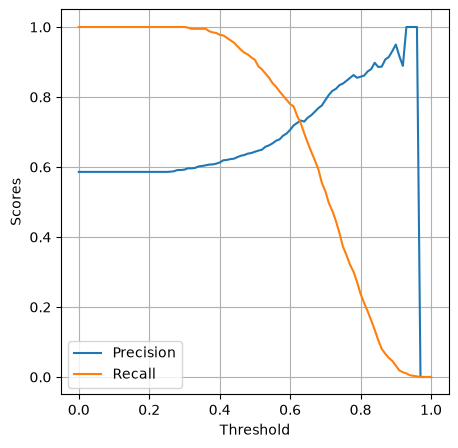

In [27]:
plt.figure(figsize=(5,5))

plt.plot(df_scores.threshold, df_scores.precision, label='Precision')
plt.plot(df_scores.threshold, df_scores.recall, label='Recall')

plt.xlabel('Threshold')
plt.ylabel('Scores')
plt.grid()

plt.legend()

### Question 4: F1 score

Precision and recall are conflicting - when one grows, the other goes down. That's why they are often combined into the F1 score - a metrics that takes into account both

This is the formula for computing F1:

$$F_1 = 2 \cdot \cfrac{P \cdot R}{P + R}$$

Where $P$ is precision and $R$ is recall.

Let's compute F1 for all thresholds from 0.0 to 1.0 with increment 0.01

At which threshold F1 is maximal?

- 0.21
- 0.41
- 0.61
- 0.81

In [28]:
df_scores['f1'] = (
    2 * df_scores.precision * df_scores.recall
    / (df_scores.precision + df_scores.recall)
).fillna(0)

In [29]:
df_scores.loc[df_scores.f1.idxmax()]

threshold    0.410000
precision    0.619048
recall       0.976109
f1           0.757616
Name: 41, dtype: float64

### Question 5: 5-Fold CV


Use the `KFold` class from Scikit-Learn to evaluate our model on 5 different folds:

```
KFold(n_splits=5, shuffle=True, random_state=1)
```

* Iterate over different folds of `df_full_train`
* Split the data into train and validation
* Train the model on train with these parameters: `LogisticRegression(solver='liblinear', C=1.0, max_iter=1000)`
* Use AUC to evaluate the model on validation

How large is standard deviation of the scores across different folds?

- 0.001
- 0.007
- 0.013
- 0.060

In [30]:
def train(df_train, y_train, C=1.0):
    dicts = df_train[categorical + numerical].to_dict(orient='records')

    dv = DictVectorizer(sparse=False)
    X_train = dv.fit_transform(dicts)

    model = LogisticRegression(solver='liblinear', C=C, max_iter=1000)
    model.fit(X_train, y_train)

    return dv, model

In [31]:
def predict(df, dv, model):
    dicts = df[categorical + numerical].to_dict(orient='records')

    X = dv.transform(dicts)
    y_pred = model.predict_proba(X)[:, 1]

    return y_pred

In [32]:
from sklearn.model_selection import KFold

In [34]:
n_splits = 5

kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

scores = []

for train_idx, val_idx in kfold.split(df_full_train):
    df_train = df_full_train.iloc[train_idx]
    df_val = df_full_train.iloc[val_idx]

    y_train = df_train.converted.values
    y_val = df_val.converted.values

    dv, model = train(df_train, y_train, C=1.0)
    y_pred = predict(df_val, dv, model)

    auc = roc_auc_score(y_val, y_pred)
    scores.append(auc)

print('%.3f +- %.3f' % (np.mean(scores), np.std(scores)))

0.732 +- 0.007


### Question 6: Hyperparameter Tuning

Now let's use 5-Fold cross-validation to find the best parameter `C`

* Iterate over the following `C` values: `[0.000001, 0.001, 1]`
* Initialize `KFold` with the same parameters as previously
* Use these parameters for the model: `LogisticRegression(solver='liblinear', C=C, max_iter=1000)`
* Compute the mean ROC AUC as well as the std (round the mean and std to 3
  decimal digits).

Which `C` leads to the best mean ROC AUC?

- 0.000001
- 0.001
- 1

If you have ties, select the score with the lowest std. If you still have ties, select the smallest `C`.

In [37]:
# %pip install tqdm

Note: you may need to restart the kernel to use updated packages.


In [38]:
from tqdm.auto import tqdm

In [42]:
n_splits = 5

for C in tqdm([0.000001, 0.001, 1]):
    kfold = KFold(n_splits=n_splits, shuffle=True, random_state=1)

    scores = []

    for train_idx, val_idx in kfold.split(df_full_train):
        df_train = df_full_train.iloc[train_idx]
        df_val = df_full_train.iloc[val_idx]

        y_train = df_train.converted.values
        y_val = df_val.converted.values

        dv, model = train(df_train, y_train, C=C)
        y_pred = predict(df_val, dv, model)

        auc = roc_auc_score(y_val, y_pred)
        scores.append(auc)

    print('C=%s %.3f +- %.3f' % (C, np.mean(scores), np.std(scores)))

 33%|████████████████████████████████████████████████████████████▋                                                                                                                         | 1/3 [00:00<00:00,  4.04it/s]

C=1e-06 0.617 +- 0.019


 67%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▎                                                            | 2/3 [00:00<00:00,  3.96it/s]

C=0.001 0.749 +- 0.010


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00,  3.99it/s]

C=1 0.732 +- 0.007
